In [1]:
from decider.dag.builder import DeciderBuilder
from decider.modules.eg1.mod import EG1Module
from decider.modules.eg2.mod import EG2Module
from decider.modules.eg3.mod import EG3Module
from decider.modules.eg4.mod import EG4Module
from decider.dag.compile import CompiledModule

/opt/miniconda/envs/dspdev/lib/python3.10/site-packages/pyspark/pandas/__init__.py:43: UserWarning: 'PYARROW_IGNORE_TIMEZONE' environment variable was not set. It is required to set this environment variable to '1' in both driver and executor sides if you use pyarrow>=2.0.0. pandas-on-Spark will set it for you but it does not work if there is a Spark context already launched.
  warnings.warn(


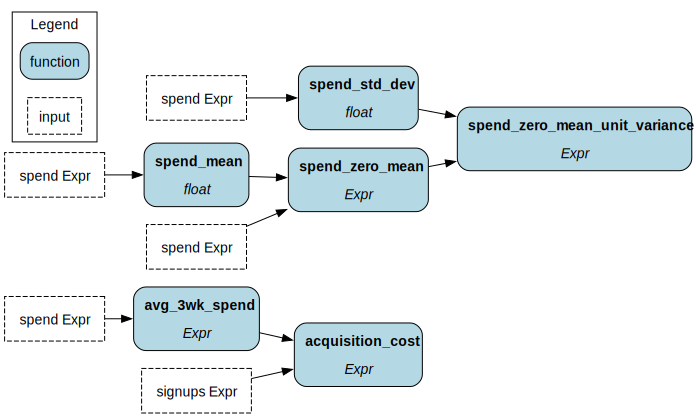

In [2]:
# Example 1 you can have modules get created from functions
dr = (
    DeciderBuilder()
    .with_config({})
    .include(EG1Module())
    .build()
)
dr

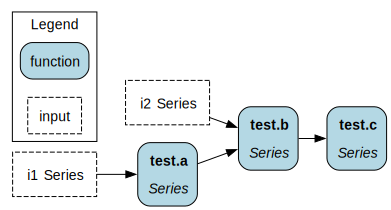

In [3]:
# Example 2 you can have modules get created in namespaces

dr = (
    DeciderBuilder()
    .with_config({})
    .include(EG2Module(), namespace="test")
    .build()
)
dr

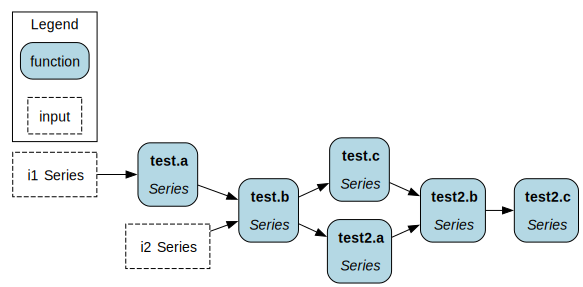

In [4]:
# Example 3 You can map outputs of one module to inputs of another
dr = (
    DeciderBuilder()
    .with_config({})
    .include(EG2Module(), namespace="test")
    .include(EG2Module(), namespace="test2", parameter_mapping={"test.c":"i2", "test.b":"i1"})
    .build()
)
dr

Point to think: When we namespace modules should we give abilities to expose variables to the global namespace as well

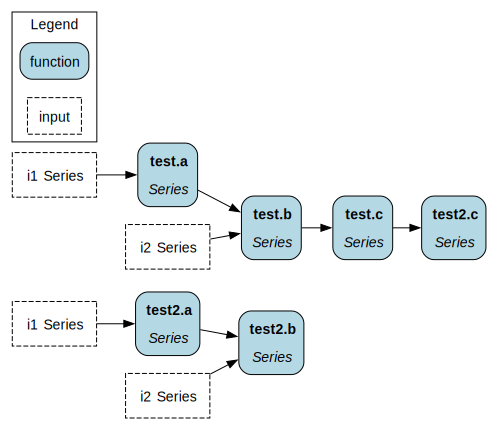

In [5]:
# Here we are replacing the function inside a module with the output of another module so its like overriding
# Notice how test2.c doesnt depend on test2.b but rather on test.c
dr = (
    DeciderBuilder()
    .with_config({})
    .include(EG2Module(), namespace="test")
    .include(EG2Module(), namespace="test2", parameter_mapping={"test.c":"b"})
    .build()
)
dr

In [6]:
# Here we try the same but override c not b but as nothing depends on c it gives an error
try:
    dr = (
        DeciderBuilder()
        .with_config({})
        .include(EG2Module(), namespace="test")
        .include(EG2Module(), namespace="test2", parameter_mapping={"test.c":"c"})
        .build()
    )
except ValueError as err:
    print(f"Raised error: \n {err}")

-------------------------------------------------------------------
Oh no an error! Need help with Hamilton?
Join our slack and ask for help! https://join.slack.com/t/hamilton-opensource/shared_invite/zt-2niepkra8-DGKGf_tTYhXuJWBTXtIs4g
-------------------------------------------------------------------



Raised error: 
 Parameter mapping(s) not found in any node: {'test.c': 'c'}. These internal parameter names don't exist in the expander's nodes.


More thinking points:
1. its confusing that test2.b still exists should we completely replace it with test.c maybe something like:
nodes["test2.b"] = Node(lambda inputs: inputs["test.c"]) <- we replacing test2.b's implementation with something that just returns test.c
--> this might be confusing so do we rename test2.b to test2.b_override to make it clear?
2. when replacing c someone might expect the output of "test2.c" to actually be "test.c" yet we throw an error. the above might solve this too. but its a trade off

In [7]:
# The below doesnt exist fully yet but i have made starts to it:
# Here is an example of compiling
from decider.modules.eg1 import funcs as eg1_funcs
import polars as pl

input_schema =  {"spend": pl.Float64, "signups": pl.Int64}
compiled_mod = CompiledModule(eg1_funcs, input_schema, output_vars=["spend_zero_mean_unit_variance", "acquisition_cost"])
compiled_mod._compile()

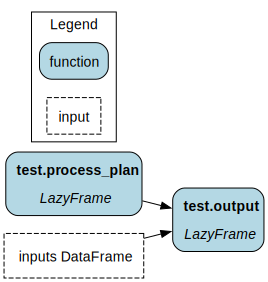

In [ ]:
# Compiling a node should reduce ti to taking in a process plan and inputs as all the operations should be bundled
dr = (
    DeciderBuilder()
    .with_config({})
    .include(EG2Module().compile(), namespace="test")
    .build()
)
dr

In [9]:
# It could be nice if we could rather than say build say compile to create a compiled node from multiple other nodes
compiled_plan = (
    DeciderBuilder()
    .with_config({})
    .include(EG1Module(), namespace="test")
    .include(EG2Module().compile(), namespace="test")
    .compile()
)
compiled_plan

CompiledModulePlaceholder(module=None)

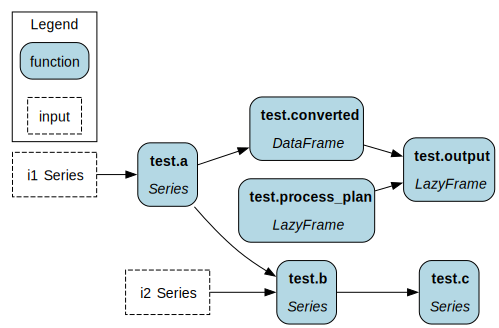

In [ ]:
# Then we could chain these like where we include a compiled plan
dr = (
    DeciderBuilder()
    .with_config({})
    .include(EG2Module(), namespace="test")
    .include(EG4Module(), namespace="test",parameter_mapping={"test.a": "input"}) # Need this for conversions
    .include(compiled_plan, namespace="test",parameter_mapping={"test.converted": "inputs"})
    .build()
)
dr

Theres a tonne of interoperability that needs to be put into place like when we working with expressions how can we pipe data through it in an efficient way.
We also need the data conversions to start working can we make use of adapters to convert the datatypes how will it affect validation.

In [ ]:
compiled_plan = (
    DeciderBuilder()
    .with_config({})
    # <- we might also need some sort of config when compiling we should probably pull it through from the builder somehow 
    # But things like a scorecard could get its config and build the whole plan with the config already compiled and we could pull out variables like 1 or 2 thresholds that cna be dynamically adjusted
    .include(EG3Module().compile(config={}), namespace="test") 
    .compile()
)
compiled_plan